In [46]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import torch
from transformers import AutoTokenizer, AutoModel
import torch.nn as nn
from torch.optim import AdamW
from torch.nn import BCEWithLogitsLoss
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, roc_curve, auc
from peft import LoraConfig, get_peft_model  # For efficient fine-tuning



#### Dataset Fetching and Preparation

In [47]:
df=pd.read_excel("E:\\ML\\BioActivity\\bioactivity_dataset.xlsx", sheet_name="Sheet1")
df.head(3)

,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
0,CHEMBL323869,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,active
1,CHEMBL327146,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,active
2,CHEMBL116620,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,4,9.0,active


In [48]:
df.describe(include='all')

,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
count,6629,6628,6629.000000,6629.000000,6629.000000,6629.000000,6629.00,6629
unique,5473,5472,NaN,NaN,NaN,NaN,NaN,2
top,CHEMBL98,O=C(CCCCCCC(=O)Nc1ccccc1)NO,NaN,NaN,NaN,NaN,NaN,active
freq,320,320,NaN,NaN,NaN,NaN,NaN,5383
mean,NaN,NaN,419.852171,3.584722,2.881883,5.550913,inf,NaN
std,NaN,NaN,120.481158,1.437887,1.132482,2.430323,NaN,NaN
min,NaN,NaN,75.067000,-14.260700,0.000000,0.000000,2.39,NaN
25%,NaN,NaN,341.411000,2.554200,2.000000,4.000000,6.17,NaN
50%,NaN,NaN,401.511000,3.478400,3.000000,5.000000,6.88,NaN
75%,NaN,NaN,481.560000,4.450500,3.000000,7.000000,7.60,NaN


In [49]:
df['pIC50']=df['pIC50'].replace(['inf', np.inf], np.nan)
df.describe(include='all')

,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
count,6629,6628,6629.000000,6629.000000,6629.000000,6629.000000,6627.000000,6629
unique,5473,5472,NaN,NaN,NaN,NaN,NaN,2
top,CHEMBL98,O=C(CCCCCCC(=O)Nc1ccccc1)NO,NaN,NaN,NaN,NaN,NaN,active
freq,320,320,NaN,NaN,NaN,NaN,NaN,5383
mean,NaN,NaN,419.852171,3.584722,2.881883,5.550913,6.752300,NaN
std,NaN,NaN,120.481158,1.437887,1.132482,2.430323,1.286299,NaN
min,NaN,NaN,75.067000,-14.260700,0.000000,0.000000,2.390000,NaN
25%,NaN,NaN,341.411000,2.554200,2.000000,4.000000,6.170000,NaN
50%,NaN,NaN,401.511000,3.478400,3.000000,5.000000,6.880000,NaN
75%,NaN,NaN,481.560000,4.450500,3.000000,7.000000,7.600000,NaN


In [50]:
df.isnull().sum()

molecule_chembl_id    0
canonical_smiles      1
MW                    0
LogP                  0
NumHDonors            0
NumHAcceptors         0
pIC50                 2
bioactivity_class     0
dtype: int64

In [51]:
df.dropna(inplace=True)
df.isnull().sum()

molecule_chembl_id    0
canonical_smiles      0
MW                    0
LogP                  0
NumHDonors            0
NumHAcceptors         0
pIC50                 0
bioactivity_class     0
dtype: int64

In [52]:
df.duplicated().sum()

285

In [53]:
df.drop(['molecule_chembl_id'], axis=1, inplace=True)

In [32]:
df.to_excel("E:\\ML\\BioActivity\\bioactivity_dataset_cleaned.xlsx", index=False)

In [54]:
df = pd.read_excel('E:\\ML\\BioActivity\\bioactivity_dataset_cleaned.xlsx')
df['mol'] = df['canonical_smiles'].apply(Chem.MolFromSmiles)
df = df.dropna(subset=['mol'])

# Compute/scale descriptors (if not already)
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return np.zeros(6)
    return np.array([Descriptors.MolWt(mol),
                Descriptors.MolLogP(mol),
                Descriptors.TPSA(mol),
                Descriptors.NumHDonors(mol),
                Descriptors.NumHAcceptors(mol),
                Descriptors.NumRotatableBonds(mol)
                ])

df[['MW', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds']] = df['canonical_smiles'].apply(compute_descriptors).tolist()

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6626 entries, 0 to 6625
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   canonical_smiles   6626 non-null   object 
 1   MW                 6626 non-null   float64
 2   LogP               6626 non-null   float64
 3   NumHDonors         6626 non-null   float64
 4   NumHAcceptors      6626 non-null   float64
 5   pIC50              6626 non-null   float64
 6   bioactivity_class  6626 non-null   object 
 7   mol                6626 non-null   object 
 8   TPSA               6626 non-null   float64
 9   NumRotatableBonds  6626 non-null   float64
dtypes: float64(7), object(3)
memory usage: 517.8+ KB


In [56]:
df['bioactivity']=df['bioactivity_class'].map({'active': 1, 'inactive': 0})
df.head(3)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class,mol,TPSA,NumRotatableBonds,bioactivity
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4.0,6.0,8.6,active,<rdkit.Chem.rdchem.Mol object at 0x00000146159...,129.65,11.0,1
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4.0,6.0,9.0,active,<rdkit.Chem.rdchem.Mol object at 0x00000146159...,133.31,10.0,1
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4.0,4.0,9.0,active,<rdkit.Chem.rdchem.Mol object at 0x0000014615A...,107.53,7.0,1


In [57]:
df.duplicated().sum()

0

In [59]:
descriptors=['MW', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds']

COMPREHENSIVE STATISTICAL ANALYSIS OF MOLECULAR DESCRIPTORS

1. DESCRIPTIVE STATISTICS BY BIOACTIVITY CLASS
--------------------------------------------------------------------------------
                     MW                           LogP                    \
                   mean         std   median      mean       std  median   
bioactivity                                                                
0            395.001567  137.605244  365.357  3.439772  1.624479  3.1718   
1            425.439613  115.677417  412.495  3.611256  1.372801  3.5418   

                   TPSA                   NumHDonors                   \
                   mean        std median       mean       std median   
bioactivity                                                             
0             88.259823  40.589501  80.93   2.272289  1.319741    2.0   
1            102.749903  34.079750  97.71   3.028248  1.038632    3.0   

            NumHAcceptors                  NumRotatableBonds    

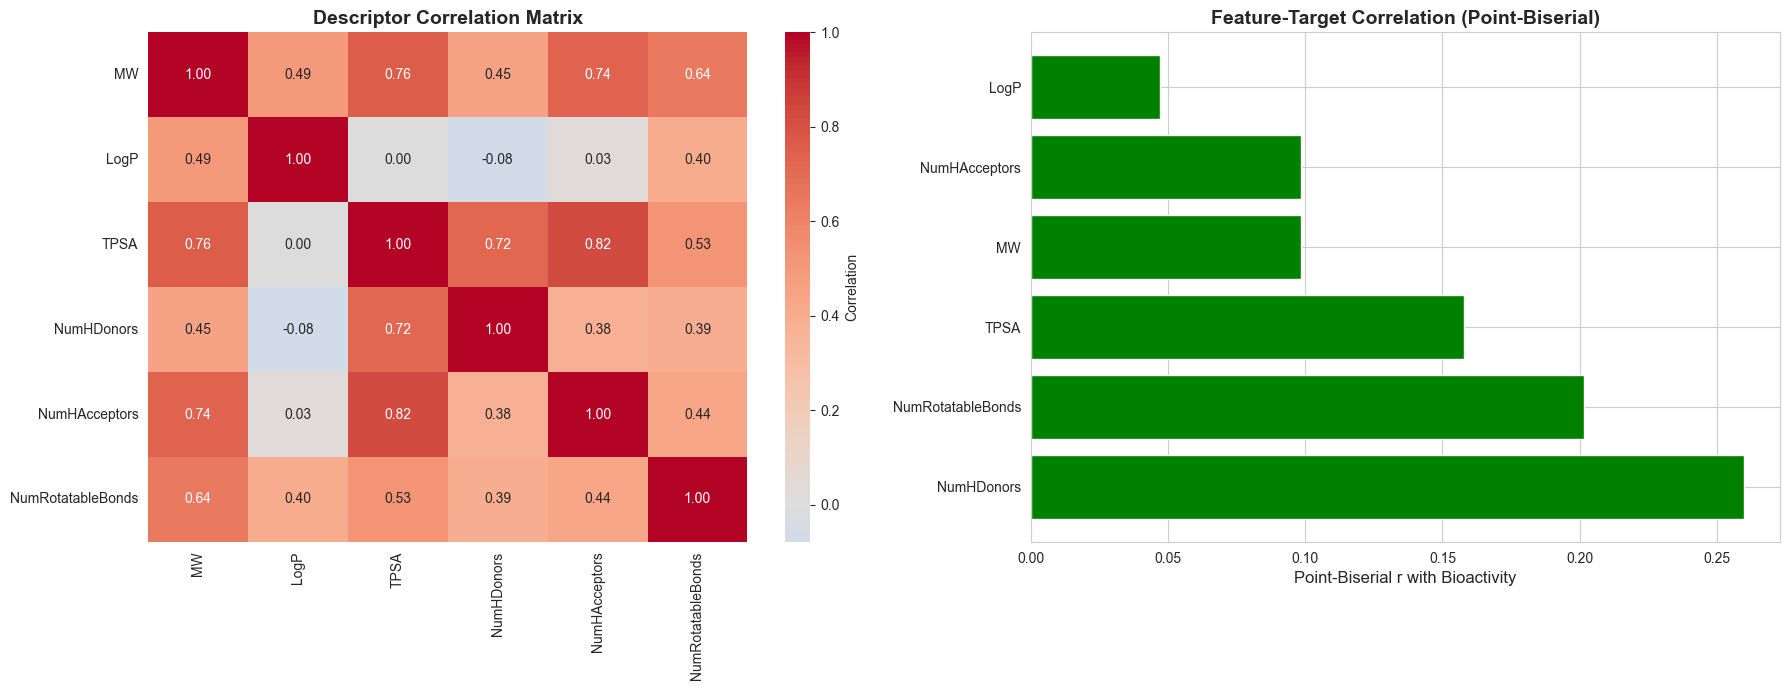


3. FEATURE-TARGET CORRELATION ANALYSIS (Point-Biserial)
--------------------------------------------------------------------------------
       Descriptor     r_pb       p-value  Abs_Corr
       NumHDonors 0.259987 8.108382e-103  0.259987
NumRotatableBonds 0.201426  1.287960e-61  0.201426
             TPSA 0.157939  2.852126e-38  0.157939
               MW 0.098533  9.083151e-16  0.098533
    NumHAcceptors 0.098303  1.059046e-15  0.098303
             LogP 0.047014  1.290113e-04  0.047014

4. MANN-WHITNEY U TEST (Active vs Inactive)
--------------------------------------------------------------------------------
       Descriptor  U-statistic       p-value  Rank_Biserial_r Effect_Size Significant
       NumHDonors    4646142.5 1.546447e-112           0.3870      medium         Yes
NumRotatableBonds    4337392.0  7.005534e-60           0.2949       small         Yes
             TPSA    4328148.0  3.057351e-58           0.2921       small         Yes
               MW    4066964.5  4.2

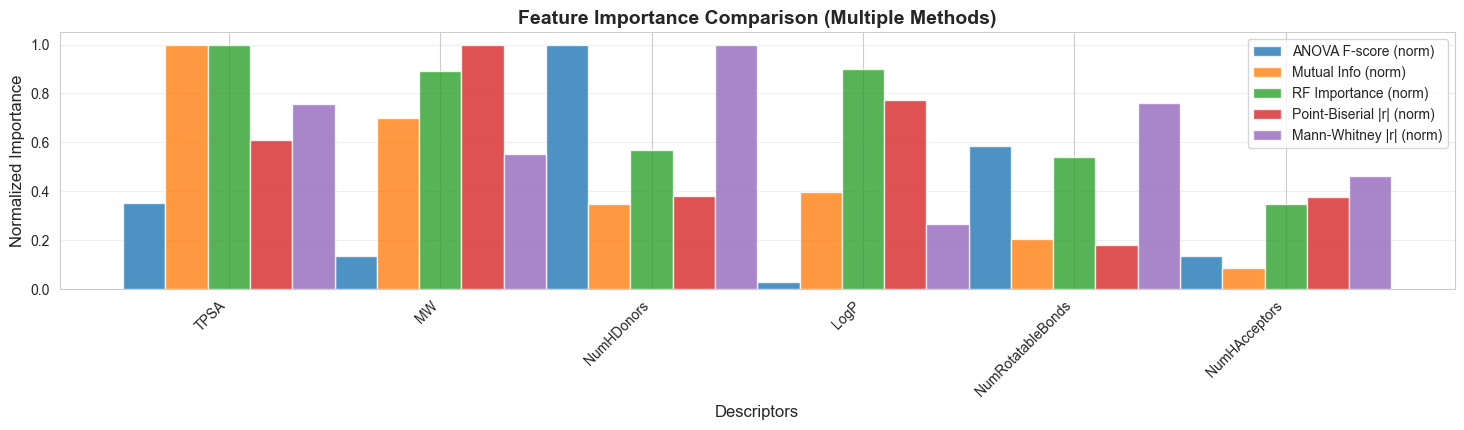


RECOMMENDATIONS FOR FEATURE SELECTION

✓ TOP FEATURES RANKING (by average rank):

✓ TOP FEATURES RANKING (by average rank):
   1. TPSA
   2. MW
   3. NumHDonors
   4. LogP
   5. NumRotatableBonds
   6. NumHAcceptors

⚠️ CONSIDER REMOVING (high multicollinearity):
   - NumHAcceptors (corr with TPSA: 0.822)

⚠️ LOW IMPORTANCE FEATURES (consider removing):

⚠️ LOW IMPORTANCE FEATURES (consider removing):
   - LogP
   - NumRotatableBonds
   - NumHAcceptors

SUGGESTED FINAL FEATURE SET:

Recommended 3 descriptors:
   1. TPSA (rank: 2.20)
   2. MW (rank: 2.80)
   3. NumHDonors (rank: 2.80)

   1. TPSA (rank: 2.20)
   2. MW (rank: 2.80)
   3. NumHDonors (rank: 2.80)



In [60]:
import seaborn as sns
from scipy.stats import shapiro, mannwhitneyu
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier
import warnings

import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

print("="*80)
print("COMPREHENSIVE STATISTICAL ANALYSIS OF MOLECULAR DESCRIPTORS")
print("="*80)

# 1. DESCRIPTIVE STATISTICS
print("\n1. DESCRIPTIVE STATISTICS BY BIOACTIVITY CLASS")
print("-"*80)
desc_stats = df.groupby('bioactivity')[descriptors].agg(['mean', 'std', 'median'])
print(desc_stats)

# 2. CORRELATION ANALYSIS
print("\n2. CORRELATION MATRIX OF DESCRIPTORS")
print("-"*80)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Correlation heatmap
corr_matrix = df[descriptors].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('Descriptor Correlation Matrix', fontsize=14, fontweight='bold')

# Find highly correlated pairs (|r| > 0.8)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'Feature1': corr_matrix.columns[i],
                'Feature2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print("\n⚠️ Highly Correlated Pairs (|r| > 0.8) - Consider removing one:")
    print(high_corr_df.to_string(index=False))

# Feature-Target correlation
# Point-Biserial is used (not Pearson) because bioactivity is binary (0/1).
# Point-Biserial = Pearson applied to a binary variable with the correct p-value.
from scipy.stats import pointbiserialr
target_corr = []
for desc in descriptors:
    r_pb, pval = pointbiserialr(df['bioactivity'], df[desc])
    target_corr.append({'Descriptor': desc, 'r_pb': r_pb, 'p-value': pval})

target_corr_df = pd.DataFrame(target_corr).sort_values('r_pb', key=abs, ascending=False)
target_corr_df['Abs_Corr'] = target_corr_df['r_pb'].abs()

# Plot feature-target correlation
axes[1].barh(target_corr_df['Descriptor'], target_corr_df['r_pb'], 
             color=['green' if x > 0 else 'red' for x in target_corr_df['r_pb']])
axes[1].set_xlabel('Point-Biserial r with Bioactivity', fontsize=12)
axes[1].set_title('Feature-Target Correlation (Point-Biserial)', fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('descriptor_correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n3. FEATURE-TARGET CORRELATION ANALYSIS (Point-Biserial)")
print("-"*80)
print(target_corr_df.to_string(index=False))

# 3. STATISTICAL TESTS (Mann-Whitney U for non-parametric comparison)
print("\n4. MANN-WHITNEY U TEST (Active vs Inactive)")
print("-"*80)
statistical_tests = []
for desc in descriptors:
    # Slice per-descriptor inside the loop — each feature gets its own groups
    active   = df[df['bioactivity'] == 1][desc].dropna()
    inactive = df[df['bioactivity'] == 0][desc].dropna()

    u_stat, pval = mannwhitneyu(active, inactive, alternative='two-sided')
    # Rank-biserial r is the correct effect size for Mann-Whitney U.
    # Cohen's d is paired with the t-test (parametric); using it here would be
    # a methodological inconsistency in a non-parametric pipeline.
    n1, n2 = len(active), len(inactive)
    r_rb = abs(1 - (2 * u_stat) / (n1 * n2))
    eff_label = 'large' if r_rb > 0.5 else ('medium' if r_rb > 0.3 else 'small')

    statistical_tests.append({
        'Descriptor': desc,
        'U-statistic': u_stat,
        'p-value': pval,
        'Rank_Biserial_r': round(r_rb, 4),
        'Effect_Size': eff_label,
        'Significant': 'Yes' if pval < 0.05 else 'No'
    })

stat_test_df = pd.DataFrame(statistical_tests).sort_values('p-value')
print(stat_test_df.to_string(index=False))

# 4. FEATURE IMPORTANCE ANALYSIS
print("\n5. FEATURE IMPORTANCE ANALYSIS (Borda Count across 5 methods)")
print("-"*80)

X = df[descriptors].values
y = df['bioactivity'].values

# ANOVA F-test
f_scores, f_pvalues = f_classif(X, y)

# Mutual Information
mi_scores = mutual_info_classif(X, y, random_state=42)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)
rf_importance = rf.feature_importances_

# Align stat_test_df to the original descriptor order so index matches
stat_test_aligned = stat_test_df.set_index('Descriptor').loc[descriptors]

# Combine all importance scores — now including Mann-Whitney rank-biserial r
# as the 5th method (non-parametric, distribution-free effect size)
importance_df = pd.DataFrame({
    'Descriptor':        descriptors,
    'ANOVA_F':           f_scores,
    'ANOVA_p':           f_pvalues,
    'Mutual_Info':       mi_scores,
    'RF_Importance':     rf_importance,
    'Point_Biserial_r':  target_corr_df['Abs_Corr'].values,  # already |r| from abs()
    'MannWhitney_r':     stat_test_aligned['Rank_Biserial_r'].values,
})

# For correlation-based scores, scientific relevance is determined by MAGNITUDE,
# not sign. A feature with r_pb = -0.8 (higher values → inactive) is equally
# discriminative as r_pb = +0.8 (higher values → active).
# Ranking on the raw signed value would incorrectly penalise strong negative
# correlations. We therefore rank on |r| for both correlation measures.
#
# Note: Point_Biserial_r is already stored as Abs_Corr (absolute value).
#       MannWhitney_r from abs(1 - 2U/n1n2) is always ≥ 0 by construction,
#       but we apply abs() defensively for correctness.
importance_df['|Point_Biserial_r|'] = importance_df['Point_Biserial_r'].abs()
importance_df['|MannWhitney_r|']     = importance_df['MannWhitney_r'].abs()

# Borda Count: rank each method 1–N (1 = most important), then average ranks.
# Lower Avg_Rank = consistently important across all methods.
# ANOVA_F, Mutual_Info, RF_Importance are always ≥ 0 — rank directly.
# Correlation columns ranked on their absolute values (see above).
rank_cols = {
    'ANOVA_F':           'ANOVA_F',
    'Mutual_Info':       'Mutual_Info',
    'RF_Importance':     'RF_Importance',
    'Point_Biserial_r':  '|Point_Biserial_r|',
    'MannWhitney_r':     '|MannWhitney_r|',
}
for rank_label, source_col in rank_cols.items():
    importance_df[f'{rank_label}_rank'] = importance_df[source_col].rank(ascending=False)

importance_df['Avg_Rank'] = importance_df[[f'{k}_rank' for k in rank_cols]].mean(axis=1)
importance_df = importance_df.sort_values('Avg_Rank')

print(importance_df[['Descriptor', 'ANOVA_F', 'Mutual_Info', 'RF_Importance',
                      '|Point_Biserial_r|', '|MannWhitney_r|', 'Avg_Rank']].to_string(index=False))

# 5. VISUALIZATIONS
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Plot 1: Feature Importance Comparison
ax1 = fig.add_subplot(gs[0, :])
x_pos = np.arange(len(descriptors))
width = 0.2

ax1.bar(x_pos - 2*width, importance_df['ANOVA_F'] / importance_df['ANOVA_F'].max(),
        width, label='ANOVA F-score (norm)', alpha=0.8)
ax1.bar(x_pos - 1*width, importance_df['Mutual_Info'] / importance_df['Mutual_Info'].max(),
        width, label='Mutual Info (norm)', alpha=0.8)
ax1.bar(x_pos + 0*width, importance_df['RF_Importance'] / importance_df['RF_Importance'].max(),
        width, label='RF Importance (norm)', alpha=0.8)
ax1.bar(x_pos + 1*width, importance_df['|Point_Biserial_r|'] / importance_df['|Point_Biserial_r|'].max(),
        width, label='Point-Biserial |r| (norm)', alpha=0.8)
ax1.bar(x_pos + 2*width, importance_df['|MannWhitney_r|'] / importance_df['|MannWhitney_r|'].max(),
        width, label='Mann-Whitney |r| (norm)', alpha=0.8)

ax1.set_xlabel('Descriptors', fontsize=12)
ax1.set_ylabel('Normalized Importance', fontsize=12)
ax1.set_title('Feature Importance Comparison (Multiple Methods)', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(importance_df['Descriptor'], rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2-7: Box plots for top 6 descriptors
# top_descriptors = importance_df.head(6)['Descriptor'].values
# for idx, desc in enumerate(top_descriptors):
#     ax = fig.add_subplot(gs[1 + idx//3, idx%3])
    
#     data_to_plot = [df[df['bioactivity'] == 0][desc], df[df['bioactivity'] == 1][desc]]
#     bp = ax.boxplot(data_to_plot, labels=['Inactive', 'Active'], patch_artist=True)
#     for patch, color in zip(bp['boxes'], colors):
#     # Color boxes
#     colors = ['lightcoral', 'lightgreen']
#     for patch, color in zip(bp['boxes'], colors):
#         patch.set_facecolor(color)
#         patch.set_alpha(0.7)
    
#     # Add mean markers
#     means = [d.mean() for d in data_to_plot]
#     ax.plot([1, 2], means, 'D', color='red', markersize=8, label='Mean')
    
#     ax.set_ylabel(desc, fontsize=11)
#     ax.set_title(f'{desc} Distribution by Class', fontsize=11, fontweight='bold')
#     ax.grid(axis='y', alpha=0.3)
    
#     # Add statistical annotation
#     pval = stat_test_df[stat_test_df['Descriptor'] == desc]['p-value'].values[0]
#     ax.text(0.5, 0.95, f'p={pval:.2e}', transform=ax.transAxes, 
#             ha='center', va='top', fontsize=9, 
#             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.savefig('descriptor_importance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. DISTRIBUTION ANALYSIS
# print("\n6. NORMALITY TESTS (Shapiro-Wilk)")
# print("-"*80)
# normality_tests = []
# for desc in descriptors:
#     stat, pval = shapiro(df[desc].sample(min(5000, len(df)), random_state=42))
#     normality_tests.append({
#         'Descriptor': desc,
#         'W-statistic': stat,
#         'p-value': pval,
#         'Normal': 'Yes' if pval > 0.05 else 'No'
#     })
    
# normality_df = pd.DataFrame(normality_tests)
# print(normality_df.to_string(index=False))

# 7. FINAL RECOMMENDATIONS
print("\n" + "="*80)
print("RECOMMENDATIONS FOR FEATURE SELECTION")
print("="*80)
print(f"\n✓ TOP FEATURES RANKING (by average rank):")
# Top features by average rank
top_features = importance_df.head(13)['Descriptor'].tolist()
print(f"\n✓ TOP FEATURES RANKING (by average rank):")
for i, feat in enumerate(top_features, 1):
    print(f"   {i}. {feat}")

# Features to consider removing (high correlation)
if high_corr_pairs:
    print(f"\n⚠️ CONSIDER REMOVING (high multicollinearity):")
    for pair in high_corr_pairs:
        # Keep the one with higher importance
        feat1_rank = importance_df[importance_df['Descriptor'] == pair['Feature1']]['Avg_Rank'].values[0]
        feat2_rank = importance_df[importance_df['Descriptor'] == pair['Feature2']]['Avg_Rank'].values[0]
        remove = pair['Feature2'] if feat1_rank < feat2_rank else pair['Feature1']
        print(f"   - {remove} (corr with {pair['Feature1'] if remove == pair['Feature2'] else pair['Feature2']}: {pair['Correlation']:.3f})")
print(f"\n⚠️ LOW IMPORTANCE FEATURES (consider removing):")
# Low importance features
low_importance = importance_df.tail(3)['Descriptor'].tolist()
print(f"\n⚠️ LOW IMPORTANCE FEATURES (consider removing):")
for feat in low_importance:
    print(f"   - {feat}")

print("\n" + "="*80)
print("SUGGESTED FINAL FEATURE SET:")
print("="*80)

# Remove highly correlated and low importance
suggested_features = [f for f in top_features if f not in low_importance]
if high_corr_pairs:
    for pair in high_corr_pairs:
        feat1_rank = importance_df[importance_df['Descriptor'] == pair['Feature1']]['Avg_Rank'].values[0]
        feat2_rank = importance_df[importance_df['Descriptor'] == pair['Feature2']]['Avg_Rank'].values[0]
        remove = pair['Feature2'] if feat1_rank < feat2_rank else pair['Feature1']
        if remove in suggested_features:
            suggested_features.remove(remove)


print(f"\nRecommended {len(suggested_features)} descriptors:")
for i, feat in enumerate(suggested_features, 1):
    feat_rank = importance_df[importance_df['Descriptor'] == feat]['Avg_Rank'].values[0]
    print(f"   {i}. {feat} (rank: {feat_rank:.2f})")
print("\n" + "="*80)

for i, feat in enumerate(suggested_features, 1):


    rank = importance_df[importance_df['Descriptor'] == feat]['Avg_Rank'].values[0]
    print(f"   {i}. {feat} (rank: {rank:.2f})")
print("\n" + "="*80)

In [61]:
df.columns

Index(['canonical_smiles', 'MW', 'LogP', 'NumHDonors', 'NumHAcceptors',
       'pIC50', 'bioactivity_class', 'mol', 'TPSA', 'NumRotatableBonds',
       'bioactivity'],
      dtype='object')

In [62]:
df.duplicated().sum()

0

In [63]:
df.drop(columns=['pIC50', 'bioactivity_class', 'mol', 'NumHAcceptors'], inplace=True)
df.head(3)

,canonical_smiles,MW,LogP,NumHDonors,TPSA,NumRotatableBonds,bioactivity
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4.0,129.65,11.0,1
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4.0,133.31,10.0,1
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4.0,107.53,7.0,1


In [64]:
df.duplicated().sum()

1132

In [67]:
dup_all = df[df.duplicated(keep=False)].copy()
dup_all = dup_all.sort_values(list(df.columns)) # sort so pairs sit adjacent

print(f"Total rows involved in duplication : {len(dup_all)} (originals + their copies)")
print(f"Duplicate copies (excess rows) : {df.duplicated().sum()}")
print()
dup_all

Total rows involved in duplication : 1512 (originals + their copies)
Duplicate copies (excess rows) : 1132



,canonical_smiles,MW,LogP,NumHDonors,TPSA,NumRotatableBonds,bioactivity
2027,C#Cc1cccc(Nc2ncnc3ccc(S(=O)(=O)n4ccc(/C=C/C(=O...,459.487,2.9118,3.0,126.21,6.0,1
6339,C#Cc1cccc(Nc2ncnc3ccc(S(=O)(=O)n4ccc(/C=C/C(=O...,459.487,2.9118,3.0,126.21,6.0,1
2026,C#Cc1cccc(Nc2ncnc3ccc(S(=O)(=O)n4ccc(/C=C/C(=O...,534.601,4.6273,3.0,132.00,7.0,1
6338,C#Cc1cccc(Nc2ncnc3ccc(S(=O)(=O)n4ccc(/C=C/C(=O...,534.601,4.6273,3.0,132.00,7.0,1
2089,C/C=C/c1sc(-c2nccs2)nc1C(=O)NCCCCC(=O)NO,366.468,2.7052,3.0,104.21,8.0,1
...,...,...,...,...,...,...,...
2277,O=C1CC[C@H](C(=O)N[C@@H](CCCCCS)C(=O)Nc2cccc(C...,431.480,2.8975,4.0,87.30,9.0,1
1746,[N-]=[N+]=NCCC(=O)Nc1ccc(C(=O)Nc2cc(N=[N+]=[N-...,365.357,4.1018,3.0,181.74,7.0,0
1752,[N-]=[N+]=NCCC(=O)Nc1ccc(C(=O)Nc2cc(N=[N+]=[N-...,365.357,4.1018,3.0,181.74,7.0,0
1743,[N-]=[N+]=NCc1cc(N=[N+]=[N-])cc(C(=O)Nc2cc(-c3...,384.403,5.9402,2.0,152.64,6.0,0


In [68]:
dup_all.to_excel("E:\\ML\\BioActivity\\bioactivity_duplicates.xlsx", index=False)

In [66]:
df[df.duplicated()].head(6)

,canonical_smiles,MW,LogP,NumHDonors,TPSA,NumRotatableBonds,bioactivity
29,C/C=C1\NC(=O)[C@H]2CSSCC/C=C/[C@H](CC(=O)N[C@H...,540.708,1.4296,4.0,142.70,2.0,1
43,C/C=C1\NC(=O)[C@@H](CS)NC(=O)[C@@H](C(C)C)NC(=...,542.724,0.8942,6.0,142.70,6.0,1
47,CC(Cc1ccc(NS(=O)(=O)c2ccccc2)cc1)C(=O)NO,334.397,2.1714,3.0,95.50,6.0,0
50,COc1ccc(S(=O)(=O)Nc2ccc(/C=C/C(=O)NO)cc2)cc1,348.380,2.0146,3.0,104.73,6.0,1
51,CC(/C=C/C(=O)NO)=C\[C@@H](C)C(=O)c1ccc(N(C)C)cc1,302.374,2.5793,2.0,69.64,6.0,1
56,O=C(CCCc1ccc(NS(=O)(=O)c2ccccc2)cc1)NO,334.397,2.3155,3.0,95.50,7.0,1


In [69]:
df.duplicated().sum()

1132

In [70]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

In [72]:
df.to_excel("E:\\ML\\BioActivity\\bioactivity_dataset_cleaned_new_v3.xlsx", index=False)

In [73]:
df= pd.read_excel('E:\\ML\\BioActivity\\bioactivity_dataset_cleaned_new_v3.xlsx')
df.head(3)

,canonical_smiles,MW,LogP,NumHDonors,TPSA,NumRotatableBonds,bioactivity
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,129.65,11,1
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,133.31,10,1
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,107.53,7,1


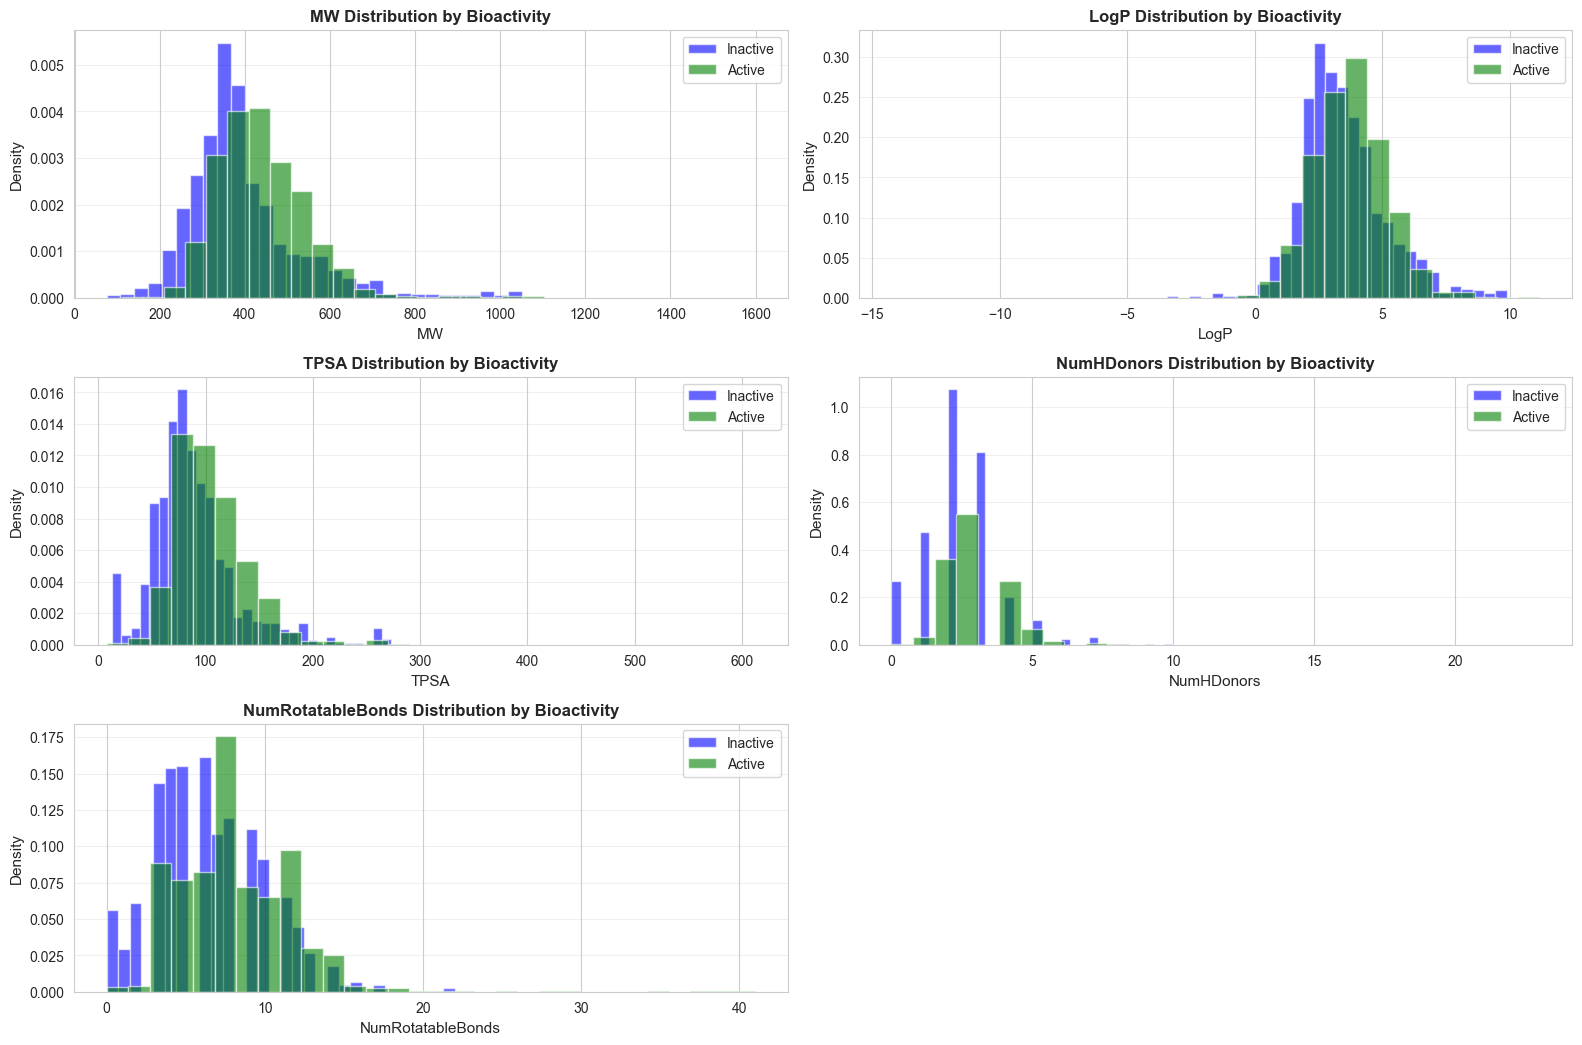

In [74]:
# Generate distribution plots for selected features
selected_features = ['MW', 'LogP', 'TPSA', 'NumHDonors', 'NumRotatableBonds']

fig, axes = plt.subplots(7, 2, figsize=(16, 24))
axes = axes.flatten()

for idx, feature in enumerate(selected_features):
    ax = axes[idx]
    
    # Plot distributions for both classes
    df[df['bioactivity'] == 0][feature].hist(ax=ax, bins=30, alpha=0.6, color='blue', label='Inactive', density=True)
    df[df['bioactivity'] == 1][feature].hist(ax=ax, bins=30, alpha=0.6, color='green', label='Active', density=True)
    
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{feature} Distribution by Bioactivity', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# Remove extra subplots
for idx in range(len(selected_features), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

#### Miscellaneous

In [ ]:
# """
# Comprehensive Statistical Testing Pipeline for Bioactivity Prediction
# Thesis-Ready Analysis Framework
# """

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy import stats
# from scipy.stats import (shapiro, normaltest, kstest, levene, mannwhitneyu, 
#                          ttest_ind, chi2_contingency, pearsonr, spearmanr,
#                          kruskal, f_oneway)
# from sklearn.preprocessing import StandardScaler
# from sklearn.feature_selection import (mutual_info_classif, f_classif, 
#                                        chi2, SelectKBest, RFE)
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import cross_val_score, StratifiedKFold
# from sklearn.metrics import (roc_auc_score, classification_report, 
#                              confusion_matrix, roc_curve)
# import warnings
# warnings.filterwarnings('ignore')

# from statsmodels.stats.outliers_influence import variance_inflation_factor


# class BioactivityStatisticalAnalysis:
#     """
#     Complete statistical analysis pipeline for bioactivity prediction.
#     Designed for thesis-level rigor and publication quality.
#     """
    
#     def __init__(self, df, target_col='bioactivity', alpha=0.05):
#         """
#         Initialize the analysis pipeline.
        
#         Args:
#             df: DataFrame with features and target
#             target_col: Name of target column
#             alpha: Significance level (default: 0.05)
#         """
#         self.df = df.copy()
#         self.target_col = target_col
#         self.alpha = alpha
#         self.features = [col for col in df.columns if col != target_col and col!='canonical_smiles']
#         self.results = {}
        
#     # ==================== PHASE 1: EXPLORATORY DATA ANALYSIS ====================
    
#     def descriptive_statistics(self):
#         """
#         Compute comprehensive descriptive statistics.
#         """
#         print("=" * 80)
#         print("PHASE 1: DESCRIPTIVE STATISTICS")
#         print("=" * 80)
        
#         desc_stats = self.df[self.features].describe().T
#         desc_stats['skewness'] = self.df[self.features].skew()
#         desc_stats['kurtosis'] = self.df[self.features].kurtosis()
#         desc_stats['missing'] = self.df[self.features].isnull().sum()
#         desc_stats['missing_pct'] = (desc_stats['missing'] / len(self.df)) * 100
        
#         print("\nDescriptive Statistics:")
#         print(desc_stats)
        
#         # Class distribution
#         print(f"\nTarget Variable Distribution:")
#         print(self.df[self.target_col].value_counts())
#         print(f"\nClass Balance: {self.df[self.target_col].value_counts(normalize=True)}")
        
#         self.results['descriptive_stats'] = desc_stats
        
#         return desc_stats
    
#     def check_class_imbalance(self):
#         """
#         Check for class imbalance and recommend techniques.
#         """
#         class_counts = self.df[self.target_col].value_counts()
#         imbalance_ratio = class_counts.max() / class_counts.min()
        
#         print(f"\n{'='*80}")
#         print("CLASS IMBALANCE ANALYSIS")
#         print(f"{'='*80}")
#         print(f"Imbalance Ratio: {imbalance_ratio:.2f}")
        
#         if imbalance_ratio > 1.5:
#             print("⚠️  RECOMMENDATION: Dataset is imbalanced!")
#             print("   Consider: SMOTE, Random Undersampling, or Class Weights")
#         else:
#             print("✓ Dataset is reasonably balanced")
        
#         self.results['imbalance_ratio'] = imbalance_ratio
#         return imbalance_ratio
    
#     # ==================== PHASE 2: NORMALITY TESTING ====================
    
#     def test_normality(self):
#         """
#         Test normality for all features using multiple tests.
#         Critical for choosing parametric vs non-parametric tests.
#         """
#         print(f"\n{'='*80}")
#         print("PHASE 2: NORMALITY TESTING")
#         print(f"{'='*80}")
        
#         normality_results = []
        
#         for feature in self.features:
#             data = self.df[feature].dropna()
            
#             # Shapiro-Wilk Test (best for n < 5000)
#             shapiro_stat, shapiro_p = shapiro(data)
            
#             # Kolmogorov-Smirnov Test
#             ks_stat, ks_p = kstest(data, 'norm', args=(data.mean(), data.std()))
            
#             # D'Agostino's K-squared test
#             k2_stat, k2_p = normaltest(data)
            
#             is_normal = all([shapiro_p > self.alpha, ks_p > self.alpha, k2_p > self.alpha])
            
#             normality_results.append({
#                 'Feature': feature,
#                 'Shapiro_p': shapiro_p,
#                 'KS_p': ks_p,
#                 'K2_p': k2_p,
#                 'Is_Normal': is_normal
#             })
        
#         normality_df = pd.DataFrame(normality_results)
#         print("\nNormality Test Results:")
#         print(normality_df.to_string(index=False))
        
#         normal_features = normality_df[normality_df['Is_Normal']]['Feature'].tolist()
#         non_normal_features = normality_df[~normality_df['Is_Normal']]['Feature'].tolist()
        
#         print(f"\n✓ Normal Features: {normal_features}")
#         print(f"✗ Non-Normal Features: {non_normal_features}")
        
#         self.results['normality'] = normality_df
#         self.results['normal_features'] = normal_features
#         self.results['non_normal_features'] = non_normal_features
        
#         return normality_df
    
#     # ==================== PHASE 3: OUTLIER DETECTION ====================
    
#     def detect_outliers(self, method='iqr'):
#         """
#         Detect outliers using multiple methods.
        
#         Args:
#             method: 'iqr', 'zscore', or 'modified_zscore'
#         """
#         print(f"\n{'='*80}")
#         print("PHASE 3: OUTLIER DETECTION")
#         print(f"{'='*80}")
        
#         outlier_summary = []
        
#         for feature in self.features:
#             data = self.df[feature].dropna()
            
#             if method == 'iqr':
#                 Q1 = data.quantile(0.25)
#                 Q3 = data.quantile(0.75)
#                 IQR = Q3 - Q1
#                 lower_bound = Q1 - 1.5 * IQR
#                 upper_bound = Q3 + 1.5 * IQR
#                 outliers = data[(data < lower_bound) | (data > upper_bound)]
                
#             elif method == 'zscore':
#                 z_scores = np.abs(stats.zscore(data))
#                 outliers = data[z_scores > 3]
                
#             elif method == 'modified_zscore':
#                 median = data.median()
#                 mad = np.median(np.abs(data - median))
#                 modified_z_scores = 0.6745 * (data - median) / mad
#                 outliers = data[np.abs(modified_z_scores) > 3.5]
            
#             outlier_summary.append({
#                 'Feature': feature,
#                 'Outlier_Count': len(outliers),
#                 'Outlier_Percentage': (len(outliers) / len(data)) * 100
#             })
        
#         outlier_df = pd.DataFrame(outlier_summary)
#         print(f"\nOutlier Detection Results ({method.upper()} method):")
#         print(outlier_df.to_string(index=False))
        
#         self.results['outliers'] = outlier_df
#         return outlier_df
    
#     # ==================== PHASE 4: FEATURE CORRELATION & MULTICOLLINEARITY ====================
    
#     def correlation_analysis(self):
#         """
#         Analyze correlations between features and with target.
#         """
#         print(f"\n{'='*80}")
#         print("PHASE 4: CORRELATION ANALYSIS")
#         print(f"{'='*80}")
        
#         # Feature-Feature Correlation
#         # Spearman (rank-based) is used instead of Pearson because normality
#         # testing (Phase 2) already confirmed features are non-normally distributed.
#         # Pearson is sensitive to outliers and skewness; Spearman is not.
#         corr_matrix = self.df[self.features].corr(method='spearman')
        
#         # Find highly correlated pairs
#         high_corr_pairs = []
#         for i in range(len(corr_matrix.columns)):
#             for j in range(i+1, len(corr_matrix.columns)):
#                 if abs(corr_matrix.iloc[i, j]) > 0.8:
#                     high_corr_pairs.append({
#                         'Feature1': corr_matrix.columns[i],
#                         'Feature2': corr_matrix.columns[j],
#                         'Spearman_rho': corr_matrix.iloc[i, j]
#             print("\n⚠️  Highly Correlated Feature Pairs (Spearman |ρ| > 0.8):")
        
#         if high_corr_pairs:
#             print("\n⚠️  Highly Correlated Feature Pairs (|r| > 0.8):")
#             print("\n✓ No highly correlated feature pairs found (Spearman)")
#             print("RECOMMENDATION: Consider removing one from each pair to reduce multicollinearity")
#         else:
#         # Point-Biserial used for continuous-vs-binary association (target is 0/1).
#         # Spearman also computed as a rank-based cross-check.
#         from scipy.stats import pointbiserialr
#         target_corr = []
#         for feature in self.features:
#             r_pb, pb_p = pointbiserialr(self.df[self.target_col], self.df[feature])
#             spearman_r, spearman_p = spearmanr(self.df[feature], self.df[self.target_col])
            
#             target_corr.append({
#                 'Feature': feature,
#                 'PointBiserial_r': r_pb,
#                 'PointBiserial_p': pb_p,
#                 'Spearman_r': spearman_r,
#                 'Spearman_p': spearman_p
#             })
        
#         target_corr_df = pd.DataFrame(target_corr)
#         print("\nFeature-Target Correlation:")
#         print(target_corr_df.to_string(index=False))
        
#         self.results['high_corr_pairs'] = high_corr_pairs
#         self.results['target_correlation'] = target_corr_df
        
#         return corr_matrix, target_corr_df
    
#     def check_multicollinearity(self):
#         """
#         Check multicollinearity using VIF (Variance Inflation Factor).
#         """
#         print(f"\n{'='*80}")
#         print("MULTICOLLINEARITY CHECK (VIF)")
#         print(f"{'='*80}")
        
#         X = self.df[self.features].dropna()
        
#         vif_data = []
#         for i, feature in enumerate(self.features):
#             vif = variance_inflation_factor(X.values, i)
#             vif_data.append({
#                 'Feature': feature,
#                 'VIF': vif,
#                 'Status': 'High' if vif > 10 else ('Moderate' if vif > 5 else 'Low')
#             })
        
#         vif_df = pd.DataFrame(vif_data)
#         print("\nVIF Results:")
#         print(vif_df.to_string(index=False))
    
#         print("\nInterpretation:")
#         print("  VIF < 5: Low multicollinearity")
#         print("  5 ≤ VIF ≤ 10: Moderate multicollinearity")
#         print("  VIF > 10: High multicollinearity (consider removing feature)")
    
#         self.results['vif'] = vif_df
#         return vif_df
    
#     # ==================== PHASE 5: GROUP COMPARISON TESTS ====================
    
#     def compare_groups_by_target(self):
#         """
#         Compare feature distributions between bioactivity classes.
#         Uses both parametric and non-parametric tests.
#         """
#         print(f"\n{'='*80}")
#         print("PHASE 5: GROUP COMPARISON TESTS")
#         print(f"{'='*80}")
        
#         comparison_results = []
        
#         classes = self.df[self.target_col].unique()
        
#         for feature in self.features:
#             groups = [self.df[self.df[self.target_col] == c][feature].dropna() 
#                      for c in classes]
            
#             # Parametric: Independent t-test (or ANOVA for >2 groups)
#             if len(classes) == 2:
#                 t_stat, t_p = ttest_ind(groups[0], groups[1])
#                 test_name = 't-test'
#                 param_stat = t_stat
#                 param_p = t_p
#             else:
#                 f_stat, f_p = f_oneway(*groups)
#                 test_name = 'ANOVA'
#                 param_stat = f_stat
#                 param_p = f_p
            
#             # Non-parametric: Mann-Whitney U (or Kruskal-Wallis for >2 groups)
#             if len(classes) == 2:
#                 u_stat, u_p = mannwhitneyu(groups[0], groups[1])
#                 nonparam_test = 'Mann-Whitney U'
#                 nonparam_stat = u_stat
#                 nonparam_p = u_p
#             else:
#                 h_stat, h_p = kruskal(*groups)
#                 nonparam_test = 'Kruskal-Wallis'
#                 nonparam_stat = h_stat
#                 nonparam_p = h_p
            
#             # Effect size (Cohen's d for 2 groups)
#             if len(classes) == 2:
#                 mean_diff = groups[0].mean() - groups[1].mean()
#                 pooled_std = np.sqrt((groups[0].std()**2 + groups[1].std()**2) / 2)
#                 cohens_d = mean_diff / pooled_std
#             else:
#                 cohens_d = np.nan
            
#             is_significant = (param_p < self.alpha) or (nonparam_p < self.alpha)
            
#             comparison_results.append({
#                 'Feature': feature,
#                 f'{test_name}_stat': param_stat,
#                 f'{test_name}_p': param_p,
#                 f'{nonparam_test}_stat': nonparam_stat,
#                 f'{nonparam_test}_p': nonparam_p,
#                 'Cohens_d': cohens_d,
#                 'Significant': is_significant
#             })
        
#         comparison_df = pd.DataFrame(comparison_results)
#         print("\nGroup Comparison Results:")
#         print(comparison_df.to_string(index=False))
        
#         significant_features = comparison_df[comparison_df['Significant']]['Feature'].tolist()
#         print(f"\n✓ Significant Features (p < {self.alpha}): {significant_features}")
        
#         self.results['group_comparison'] = comparison_df
#         self.results['significant_features'] = significant_features
        
#         return comparison_df
    
#     # ==================== PHASE 6: FEATURE IMPORTANCE & SELECTION ====================
    
#     def feature_importance_analysis(self):
#         """
#         Multiple feature importance methods for robust selection.
#         """
#         print(f"\n{'='*80}")
#         print("PHASE 6: FEATURE IMPORTANCE ANALYSIS")
#         print(f"{'='*80}")
        
#         X = self.df[self.features]
#         y = self.df[self.target_col]
        
#         importance_results = pd.DataFrame({'Feature': self.features})
        
#         # 1. ANOVA F-statistic
#         f_scores, f_pvalues = f_classif(X, y)
#         importance_results['ANOVA_F'] = f_scores
#         importance_results['ANOVA_p'] = f_pvalues
        
#         # 2. Mutual Information
#         mi_scores = mutual_info_classif(X, y, random_state=42)
#         importance_results['Mutual_Info'] = mi_scores
        
#         # 3. Random Forest Importance
#         rf = RandomForestClassifier(n_estimators=100, random_state=42)
#         rf.fit(X, y)
#         importance_results['RF_Importance'] = rf.feature_importances_
        
#         # 4. Logistic Regression Coefficients
#         lr = LogisticRegression(random_state=42, max_iter=1000)
#         lr.fit(StandardScaler().fit_transform(X), y)
#         importance_results['LR_Coef'] = np.abs(lr.coef_[0])
        
#         # Rank features
#         importance_results['Avg_Rank'] = (
#             importance_results['ANOVA_F'].rank(ascending=False) +
#             importance_results['Mutual_Info'].rank(ascending=False) +
#             importance_results['RF_Importance'].rank(ascending=False) +
#             importance_results['LR_Coef'].rank(ascending=False)
#         ) / 4
        
#         importance_results = importance_results.sort_values('Avg_Rank')
        
#         print("\nFeature Importance Results:")
#         print(importance_results.to_string(index=False))
        
#         self.results['feature_importance'] = importance_results
#         return importance_results
    
#     # ==================== PHASE 7: MODEL VALIDATION TESTS ====================
    
#     def cross_validation_analysis(self, models=None):
#         """
#         Perform cross-validation with multiple models and statistical comparison.
#         """
#         print(f"\n{'='*80}")
#         print("PHASE 7: CROSS-VALIDATION & MODEL COMPARISON")
#         print(f"{'='*80}")
        
#         if models is None:
#             models = {
#                 'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
#                 'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
#             }
        
#         X = self.df[self.features]
#         y = self.df[self.target_col]
        
#         cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
#         cv_results = []
        
#         for name, model in models.items():
#             scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
            
#             cv_results.append({
#                 'Model': name,
#                 'Mean_AUC': scores.mean(),
#                 'Std_AUC': scores.std(),
#                 'Min_AUC': scores.min(),
#                 'Max_AUC': scores.max(),
#                 'CV_Scores': scores
#             })
        
#         cv_df = pd.DataFrame(cv_results)
#         # Statistical comparison between models
#         # CV scores from two models on the SAME folds are PAIRED observations.
#         # ttest_ind (independent samples) is WRONG here — it ignores the pairing
#         # and produces anti-conservative p-values.
#         # Wilcoxon signed-rank test is used: it is (a) paired, (b) non-parametric
#         # (CV scores are not guaranteed normal), and (c) standard in ML literature
#         # for comparing classifiers (Demsar, 2006, JMLR).
#         if len(models) == 2:
#             from scipy.stats import wilcoxon
#             model_names = list(models.keys())
#             scores1 = cv_df[cv_df['Model'] == model_names[0]]['CV_Scores'].values[0]
#             scores2 = cv_df[cv_df['Model'] == model_names[1]]['CV_Scores'].values[0]
            
#             # Wilcoxon requires the two arrays to differ in at least one position
#             if np.all(scores1 == scores2):
#                 print("\nModel comparison: scores are identical across all folds.")
#             else:
#                 w_stat, p_value = wilcoxon(scores1, scores2)
#                 print(f"\nWilcoxon Signed-Rank Test (paired, non-parametric model comparison):")
#                 print(f"  W-statistic: {w_stat:.4f}")
#                 print(f"  p-value: {p_value:.4f}")
#                 print(f"  {model_names[0]} mean AUC: {scores1.mean():.4f} ± {scores1.std():.4f}")
#                 print(f"  {model_names[1]} mean AUC: {scores2.mean():.4f} ± {scores2.std():.4f}")
                
#                 if p_value < self.alpha:
#                     better = model_names[0] if scores1.mean() > scores2.mean() else model_names[1]
#                     print(f"  ✓ Models are significantly different (p < {self.alpha}); {better} performs better")
#                 else:
#                     print(f"  ✗ No significant difference between models (p = {p_value:.4f})")
#         print(f"\n{'='*80}")
#         self.results['cv_results'] = cv_df
#         return cv_df
    
#     # ==================== PHASE 8: GENERATE COMPREHENSIVE REPORT ====================
    
#     def generate_thesis_report(self, output_file='statistical_analysis_report.txt'):
#         """
#         Generate a comprehensive thesis-ready statistical report.
#         """
#         print(f"\n{'='*80}")
#         print("GENERATING COMPREHENSIVE THESIS REPORT")
#         print(f"{'='*80}")
        
#         with open(output_file, 'w') as f:
#             f.write("="*80 + "\n")
#             f.write("STATISTICAL ANALYSIS REPORT FOR BIOACTIVITY PREDICTION\n")
#             f.write("Thesis-Ready Comprehensive Analysis\n")
#             f.write("="*80 + "\n\n")
            
#             # Section 1: Dataset Overview
#             f.write("1. DATASET OVERVIEW\n")
#             f.write("-" * 80 + "\n")
#             f.write(f"Total Samples: {len(self.df)}\n")
#             f.write(f"Number of Features: {len(self.features)}\n")
#             f.write(f"Target Variable: {self.target_col}\n")
#             f.write(f"Class Distribution:\n{self.df[self.target_col].value_counts()}\n\n")
            
#             # Section 2: Descriptive Statistics
#             if 'descriptive_stats' in self.results:
#                 f.write("2. DESCRIPTIVE STATISTICS\n")
#                 f.write("-" * 80 + "\n")
#                 f.write(self.results['descriptive_stats'].to_string())
#                 f.write("\n\n")
            
#             # Section 3: Normality Assessment
#             if 'normality' in self.results:
#                 f.write("3. NORMALITY ASSESSMENT\n")
#                 f.write("-" * 80 + "\n")
#                 f.write(self.results['normality'].to_string(index=False))
#                 f.write("\n\n")
            
#             # Section 4: Outlier Analysis
#             if 'outliers' in self.results:
#                 f.write("4. OUTLIER ANALYSIS\n")
#                 f.write("-" * 80 + "\n")
#                 f.write(self.results['outliers'].to_string(index=False))
#                 f.write("\n\n")
            
#             # Section 5: Correlation Analysis
#             if 'target_correlation' in self.results:
#                 f.write("5. FEATURE-TARGET CORRELATION\n")
#                 f.write("-" * 80 + "\n")
#                 f.write(self.results['target_correlation'].to_string(index=False))
#                 f.write("\n\n")
            
#             # Section 6: Multicollinearity
#             if 'vif' in self.results:
#                 f.write("6. MULTICOLLINEARITY ASSESSMENT (VIF)\n")
#                 f.write("-" * 80 + "\n")
#                 f.write(self.results['vif'].to_string(index=False))
#                 f.write("\n\n")
            
#             # Section 7: Group Comparison
#             if 'group_comparison' in self.results:
#                 f.write("7. GROUP COMPARISON TESTS\n")
#                 f.write("-" * 80 + "\n")
#                 f.write(self.results['group_comparison'].to_string(index=False))
#                 f.write("\n\n")
            
#             # Section 8: Feature Importance
#             if 'feature_importance' in self.results:
#                 f.write("8. FEATURE IMPORTANCE ANALYSIS\n")
#                 f.write("-" * 80 + "\n")
#                 f.write(self.results['feature_importance'].to_string(index=False))
#                 f.write("\n\n")
            
#             # Section 9: Model Validation
#             if 'cv_results' in self.results:
#                 f.write("9. CROSS-VALIDATION RESULTS\n")
#                 f.write("-" * 80 + "\n")
#                 cv_display = self.results['cv_results'][['Model', 'Mean_AUC', 'Std_AUC', 'Min_AUC', 'Max_AUC']]
#                 f.write(cv_display.to_string(index=False))
#                 f.write("\n\n")
            
#             # Section 10: Recommendations
#             f.write("10. STATISTICAL RECOMMENDATIONS\n")
#             f.write("-" * 80 + "\n")
            
#             if 'non_normal_features' in self.results and self.results['non_normal_features']:
#                 f.write(f"• Non-normal features detected: {self.results['non_normal_features']}\n")
#                 f.write("  Recommendation: Use non-parametric tests or data transformation\n\n")
            
#             if 'high_corr_pairs' in self.results and self.results['high_corr_pairs']:
#                 f.write("• Highly correlated features detected\n")
#                 f.write("  Recommendation: Consider feature selection to reduce multicollinearity\n\n")
            

#             if 'significant_features' in self.results:
#                 f.write(f"• Statistically significant features: {self.results['significant_features']}\n")
#                 f.write("  Recommendation: Prioritize these features in modeling\n\n")



#             return output_file

#             f.write("="*80 + "\n")        
#             f.write("END OF REPORT\n")        
#             f.write("="*80 + "\n")
#             print(f"\n✓ Comprehensive report saved to: {output_file}")

In [49]:
df.head(3)

,canonical_smiles,MW,LogP,NumHDonors,TPSA,NumRotatableBonds,FractionCSP3,RingCount,bioactivity
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4.0,129.65,11.0,0.280000,3.0,1
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4.0,133.31,10.0,0.222222,4.0,1
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4.0,107.53,7.0,0.041667,3.0,1


In [50]:
# ==================== EXAMPLE USAGE ====================
print("="*80)
print("BIOACTIVITY PREDICTION - STATISTICAL ANALYSIS PIPELINE")
print("="*80)
print("\nNote: This is a demonstration with limited data.")
print("Load your complete dataset for full analysis.\n")

# Initialize analyzer
analyzer = BioactivityStatisticalAnalysis(df, target_col='bioactivity')

# Run complete analysis pipeline
print("\nRunning Complete Statistical Analysis Pipeline...\n")

# Phase 1: Descriptive Statistics
analyzer.descriptive_statistics()
analyzer.check_class_imbalance()

# Phase 2: Normality Testing
analyzer.test_normality()

# Phase 3: Outlier Detection
analyzer.detect_outliers(method='iqr')

# Phase 4: Correlation & Multicollinearity
analyzer.correlation_analysis()
analyzer.check_multicollinearity()

# Phase 5: Group Comparison (requires both classes in real data)
analyzer.compare_groups_by_target()

# Phase 6: Feature Importance
analyzer.feature_importance_analysis()

# Phase 7: Cross-Validation (requires both classes in real data)
analyzer.cross_validation_analysis()

# Phase 8: Generate Report
analyzer.generate_thesis_report()

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print("\nFor your thesis, run this with your complete dataset.")
print("The pipeline will generate publication-ready statistical results.")

BIOACTIVITY PREDICTION - STATISTICAL ANALYSIS PIPELINE

Note: This is a demonstration with limited data.
Load your complete dataset for full analysis.


Running Complete Statistical Analysis Pipeline...

PHASE 1: DESCRIPTIVE STATISTICS

Descriptive Statistics:
                    count        mean         std      min         25%  \
MW                 6341.0  422.954151  120.555783  75.0670  345.149000   
LogP               6341.0    3.600538    1.432721 -14.2607    2.573200   
NumHDonors         6341.0    2.890869    1.149988   0.0000    2.000000   
TPSA               6341.0  100.649073   36.177585   7.7600   78.430000   
NumRotatableBonds  6341.0    7.700678    3.330575   0.0000    5.000000   
FractionCSP3       6341.0    0.298070    0.174932   0.0000    0.166667   
RingCount          6341.0    3.275193    1.340746   0.0000    2.000000   

                          50%         75%        max  skewness   kurtosis  \
MW                 406.526000  486.616000  1598.7560  1.684853   8.09

In [51]:
scaler = StandardScaler()
desc_cols = ['MW', 'LogP', 'TPSA', 'NumHDonors',  'NumRotatableBonds', 'FractionCSP3', 'RingCount']
df[desc_cols] = scaler.fit_transform(df[desc_cols])

In [4]:
df.head(3)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class,bioactivity,mol,TPSA,NumRotatableBonds,NumAromaticRings,FractionCSP3
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,0.524109,0.241522,1.32487,0.282913,8.6,active,1,<rdkit.Chem.rdchem.Mol object at 0x00000222838...,1.117016,1.146765,0.274162,-0.064181
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,0.732961,0.621072,1.32487,0.282913,9.0,active,1,<rdkit.Chem.rdchem.Mol object at 0x00000222838...,1.243444,0.815502,1.181684,-0.403666
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,0.036571,-0.025903,1.32487,-0.713216,9.0,active,1,<rdkit.Chem.rdchem.Mol object at 0x00000222838...,0.352922,-0.178287,0.274162,-1.464556


In [5]:
df.drop(columns=['pIC50', 'bioactivity_class'], inplace=True)

In [6]:
df.iloc[0]['canonical_smiles']

'O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc12)NO'

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5667 entries, 0 to 5666
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   canonical_smiles   5667 non-null   object 
 1   MW                 5667 non-null   float64
 2   LogP               5667 non-null   float64
 3   NumHDonors         5667 non-null   float64
 4   NumHAcceptors      5667 non-null   float64
 5   bioactivity        5667 non-null   int64  
 6   mol                5667 non-null   object 
 7   TPSA               5667 non-null   float64
 8   NumRotatableBonds  5667 non-null   float64
 9   NumAromaticRings   5667 non-null   float64
 10  FractionCSP3       5667 non-null   float64
dtypes: float64(8), int64(1), object(2)
memory usage: 487.1+ KB


In [8]:
df['bioactivity'].value_counts()

bioactivity
1    4641
0    1026
Name: count, dtype: int64

In [9]:
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTENC


train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['bioactivity'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

tokenizer = AutoTokenizer.from_pretrained('ibm/MoLFormer-XL-both-10pct', trust_remote_code=True)
#tokenizer = AutoTokenizer.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')

class BioactivityDataset(Dataset):
    def __init__(self, df, tokenizer, desc_scaler):
        self.smiles = df['canonical_smiles'].tolist()
        self.labels = df['bioactivity'].tolist()
        self.descs = df[desc_cols].values
        #self.desc_scaler = desc_scaler
        self.encodings = tokenizer(self.smiles, truncation=True, padding=True, max_length=512, return_tensors='pt')
    
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        item['descriptors'] = torch.tensor(self.descs[idx], dtype=torch.float)
        return item

In [10]:
train_dataset = BioactivityDataset(train_df, tokenizer, scaler)
val_dataset = BioactivityDataset(val_df, tokenizer, scaler)
test_dataset = BioactivityDataset(test_df, tokenizer, scaler)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [11]:
train_df['bioactivity'].value_counts(), val_df['bioactivity'].value_counts(), test_df['bioactivity'].value_counts()

(bioactivity
 1    3712
 0     821
 Name: count, dtype: int64,
 bioactivity
 1    454
 0    113
 Name: count, dtype: int64,
 bioactivity
 1    475
 0     92
 Name: count, dtype: int64)

In [12]:
train_dataset[0]

{'input_ids': tensor([ 0,  4, 10,  4,  6, 12,  9,  7, 26,  4,  6,  4,  4,  4,  4,  4,  4,  4,
          6, 12,  9,  7, 10,  5,  8,  5,  5,  5,  5,  6, 21,  5, 11,  5,  5,  5,
          5,  5, 11,  7,  5,  8,  7, 12, 10, 33,  9,  1,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       

In [27]:
class FineTunedMultimodalModel(nn.Module):
    def __init__(self, num_desc=8, emb_dim=768, hidden=512, dropout=0.5, num_layers_to_unfreeze=10, attn_heads=8):
        super().__init__()
        self.bert = AutoModel.from_pretrained("ibm/MoLFormer-XL-both-10pct", trust_remote_code=True)

        # ---------- UNFROEZE ----------
        for p in self.bert.parameters():
            p.requires_grad = False
        for layer in self.bert.encoder.layer[-num_layers_to_unfreeze:]:
            for p in layer.parameters():
                p.requires_grad = True

        self.desc_proj = nn.Sequential(
            nn.Linear(num_desc, emb_dim),
            nn.LayerNorm(emb_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # ---------- ATTENTION FUSION ----------
        self.attn = nn.MultiheadAttention(
            embed_dim=emb_dim, num_heads=attn_heads, dropout=dropout, batch_first=True
        )

        # ---------- CLASSIFIER ----------
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1)          # logits
        )

    def forward(self, input_ids, attention_mask, descriptors):
        # BERT
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        cls_ = out.last_hidden_state[:, 0]
        mean_pool = out.last_hidden_state.mean(1)
        smiles = (cls_ + mean_pool) / 2

        # Descriptors
        desc = self.desc_proj(descriptors)                  # [B,768]

        # Attention (descriptor attends to SMILES)
        q = desc.unsqueeze(1)                               # [B,1,768]
        kv = smiles.unsqueeze(1)
        attn_out, _ = self.attn(q, kv, kv)                  # [B,1,768]
        attn_out = attn_out.squeeze(1)

        # Fuse
        fused = torch.cat([smiles, attn_out], dim=1)        # [B,1536]
        return self.classifier(fused).squeeze(-1)

model = FineTunedMultimodalModel(num_layers_to_unfreeze=12, attn_heads=8)  # Start with 4 for small data
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

FineTunedMultimodalModel(
  (bert): MolformerModel(
    (embeddings): MolformerEmbeddings(
      (word_embeddings): Embedding(2362, 768, padding_idx=2)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (encoder): MolformerEncoder(
      (layer): ModuleList(
        (0-11): 12 x MolformerLayer(
          (attention): MolformerAttention(
            (self): MolformerSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (rotary_embeddings): MolformerRotaryEmbedding()
              (feature_map): MolformerFeatureMap(
                (kernel): ReLU()
              )
            )
            (output): MolformerSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          

#### Another model

In [ ]:
class AttentionFusion(nn.Module):
    """
    Cross-attention between SMILES and descriptors
    This learns which parts of each modality are most relevant
    """
    def __init__(self, emb_dim=768, num_heads=8, dropout=0.3):
        super().__init__()
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=emb_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.layer_norm = nn.LayerNorm(emb_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, smiles_emb, desc_emb):
        # Cross-attend: descriptors attend to SMILES
        desc_emb = desc_emb.unsqueeze(1)  # [batch, 1, emb_dim]
        smiles_emb = smiles_emb.unsqueeze(1)  # [batch, 1, emb_dim]
        
        attended, _ = self.cross_attention(
            query=desc_emb,
            key=smiles_emb,
            value=smiles_emb
        )
        
        # Residual connection
        fused = self.layer_norm(desc_emb + self.dropout(attended))
        return fused.squeeze(1)


class ImprovedMultimodalModel(nn.Module):
    """
    Improvement Strategy 1: Better fusion with attention
    Expected gain: +1-2% accuracy
    """
    def __init__(self, num_desc=8, emb_dim=768, hidden_dim=512, 
                 dropout=0.3, num_layers_to_unfreeze=3):
        super().__init__()
        
        # ChemBERTa encoder
        self.smiles_encoder = AutoModel.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')
        
        # Freeze all except last layers
        for param in self.smiles_encoder.parameters():
            param.requires_grad = False
        
        # Unfreeze last N transformer layers
        unfreeze_modules = self.smiles_encoder.encoder.layer[-num_layers_to_unfreeze:]
        for module in unfreeze_modules:
            for param in module.parameters():
                param.requires_grad = True
        
        # Enhanced descriptor processing
        self.desc_proj = nn.Sequential(
            nn.Linear(num_desc, emb_dim // 2),
            nn.LayerNorm(emb_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim // 2, emb_dim),
            nn.LayerNorm(emb_dim)
        )
        
        # Attention-based fusion
        self.attention_fusion = AttentionFusion(emb_dim, num_heads=8, dropout=dropout)
        
        # Classification head with residual connections
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout / 2),  # Less dropout in final layers
            nn.Linear(hidden_dim // 4, 1)
        )
        
    def forward(self, input_ids=None, attention_mask=None, descriptors=None, **kwargs):
        # SMILES encoding
        outputs = self.smiles_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            **kwargs
        )
        
        # Use [CLS] token
        smiles_emb = torch.mean(out.last_hidden_state, dim=1)
        
        # Descriptor encoding
        desc_emb = self.desc_proj(descriptors)
        
        # Attention fusion
        fused_desc = self.attention_fusion(smiles_emb, desc_emb)
        
        # Concatenate for final prediction
        combined = torch.cat([smiles_emb, fused_desc], dim=-1)
        
        return self.classifier(combined).squeeze(-1)

model = ImprovedMultimodalModel(num_desc=4, num_layers_to_unfreeze=2)
model.to(device)

ImprovedMultimodalModel(
  (smiles_encoder): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(767, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (

In [34]:
class ChemBERTaClassifier(nn.Module):
    def __init__(self, model_name, num_num_feats=4, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.fc_concat = nn.Linear(self.bert.config.hidden_size + num_num_feats, 128)
        self.fc_out = nn.Linear(128, 1)

    def forward(self, input_ids, attention_mask, num_feats):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.pooler_output  # [CLS] token representation
        concat = torch.cat([pooled, num_feats], dim=1)
        x = self.dropout(torch.relu(self.fc_concat(concat)))
        return torch.sigmoid(self.fc_out(x)).squeeze()

In [39]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig( task_type=TaskType.SEQ_CLS, r=4, lora_alpha=8, target_modules=["query", "value"], lora_dropout=0.1)

In [40]:
model = get_peft_model(model, lora_config)
 
# Print trainable params (should be <1% of total)
model.print_trainable_parameters()  

trainable params: 1,026,561 || all params: 48,747,138 || trainable%: 2.1059


#### Train and evaluation

In [28]:
from sklearn.utils.class_weight import compute_class_weight
import torch.optim as optim

class_weights = compute_class_weight('balanced', classes=np.unique(train_df['bioactivity']), y=train_df['bioactivity'])
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

pos_weight = torch.tensor([3712 / 821]).to(device)  # From your imbalance
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)  # Added weight decay
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)  # New: Better convergence
num_train_steps = len(train_loader) * 30
warmup_steps    = int(0.1 * num_train_steps)

scheduler = optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda step: min(step/warmup_steps, 1) * \
                           (0.5 * (1 + np.cos(np.pi * step / num_train_steps)))
)

# criterion = BCEWithLogitsLoss(pos_weight=class_weights[1])
epochs = 50  # Longer for fine-tuning
best_auc = 0
patience, counter = 7, 0

In [29]:
from sklearn.metrics import precision_recall_curve

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        descriptors = batch['descriptors'].to(device)
        labels = batch['labels'].float().to(device)
        
        optimizer.zero_grad()
        logits = model(input_ids=input_ids, attention_mask=attention_mask, descriptors=descriptors)
        loss = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()
        scheduler.step()  # Step LR scheduler per batch
        train_loss += loss.item()
    
    
    # Validation
    model.eval()
    val_preds, val_labels = [], []
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            descriptors = batch['descriptors'].to(device)
            labels = batch['labels'].to(device)
            logits = model(input_ids, attention_mask, descriptors)
            probs = torch.sigmoid(logits).cpu().numpy()
            val_preds.extend(probs)
            val_labels.extend(labels.cpu().numpy())
            loss = criterion(logits, labels.float())  # Compute loss for this batch
            val_loss += loss.item()  #
    
    
    auc = roc_auc_score(val_labels, val_preds)
    prec, rec, thr = precision_recall_curve(val_labels, val_preds)
    f1s = 2*prec*rec/(prec+rec+1e-8)
    best_thr = thr[np.argmax(f1s)]
    preds = (np.array(val_preds) > best_thr).astype(int)
    acc = accuracy_score(val_labels, preds)
    f1  = f1_score(val_labels, preds)

    print(f'Epoch {epoch+1:02d} | '
          f'TrainLoss {train_loss/len(train_loader):.4f} | '
          f'ValAUROC {auc:.4f} | Acc {acc:.4f} | F1 {f1:.4f} | Thr {best_thr:.3f}')
    
    if auc > best_auc:
        best_auc = auc
        torch.save(model, 'best_finetuned_model_tt.pth')
        counter = 0
    else:
        counter += 1
        if counter >= 7:
            print("Early stopping!")
            break

Epoch 01 | TrainLoss 2.7642 | ValAUROC 0.5065 | Acc 0.7989 | F1 0.8882 | Thr 0.444
Epoch 02 | TrainLoss 2.2406 | ValAUROC 0.6772 | Acc 0.8166 | F1 0.8964 | Thr 0.558
Epoch 03 | TrainLoss 1.4867 | ValAUROC 0.7648 | Acc 0.8430 | F1 0.9095 | Thr 0.658
Epoch 04 | TrainLoss 0.8824 | ValAUROC 0.8039 | Acc 0.8607 | F1 0.9176 | Thr 0.700
Epoch 05 | TrainLoss 0.6182 | ValAUROC 0.8657 | Acc 0.8713 | F1 0.9242 | Thr 0.665
Epoch 06 | TrainLoss 0.4950 | ValAUROC 0.8979 | Acc 0.8854 | F1 0.9324 | Thr 0.673
Epoch 07 | TrainLoss 0.4115 | ValAUROC 0.8967 | Acc 0.8889 | F1 0.9336 | Thr 0.586
Epoch 08 | TrainLoss 0.3605 | ValAUROC 0.8992 | Acc 0.8995 | F1 0.9386 | Thr 0.845
Epoch 09 | TrainLoss 0.3108 | ValAUROC 0.9225 | Acc 0.8995 | F1 0.9389 | Thr 0.630
Epoch 10 | TrainLoss 0.2773 | ValAUROC 0.8997 | Acc 0.9101 | F1 0.9451 | Thr 0.679
Epoch 11 | TrainLoss 0.2603 | ValAUROC 0.9052 | Acc 0.9101 | F1 0.9447 | Thr 0.720
Epoch 12 | TrainLoss 0.2276 | ValAUROC 0.9098 | Acc 0.9136 | F1 0.9475 | Thr 0.765
Epoc

In [30]:
loaded_model = torch.load('best_finetuned_model_tt.pth', map_location=device, weights_only=False)
loaded_model.eval()


FineTunedMultimodalModel(
  (bert): MolformerModel(
    (embeddings): MolformerEmbeddings(
      (word_embeddings): Embedding(2362, 768, padding_idx=2)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (encoder): MolformerEncoder(
      (layer): ModuleList(
        (0-11): 12 x MolformerLayer(
          (attention): MolformerAttention(
            (self): MolformerSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (rotary_embeddings): MolformerRotaryEmbedding()
              (feature_map): MolformerFeatureMap(
                (kernel): ReLU()
              )
            )
            (output): MolformerSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          

In [54]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# Run inference on test set
model.eval()
test_preds = []
test_labels = []
test_probs = []
with torch.no_grad():
	for batch in test_loader:
		input_ids = batch['input_ids'].to(device)
		attention_mask = batch['attention_mask'].to(device)
		descriptors = batch['descriptors'].to(device)
		labels = batch['labels'].to(device)
		logits = model(input_ids, attention_mask, descriptors)
		probs = torch.sigmoid(logits).cpu().numpy()
		test_probs.extend(probs)
		test_preds.extend((probs > 0.794).astype(int))
		test_labels.extend(labels.cpu().numpy())

accuracy = balanced_accuracy_score(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_probs)
print(f"AUC: {auc}")
print(f"Accuracy: {accuracy}")
print("accuracy another: ", accuracy_score(test_labels, test_preds))

AUC: 0.93512585812357
Accuracy: 0.8504462242562929
accuracy another:  0.9329805996472663


In [53]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

test_preds = []
test_labels = []
test_probs = []
with torch.no_grad():
	for batch in test_loader:
		input_ids = batch['input_ids'].to(device)
		attention_mask = batch['attention_mask'].to(device)
		descriptors = batch['descriptors'].to(device)
		labels = batch['labels'].to(device)
		logits = loaded_model(input_ids, attention_mask, descriptors)
		probs = torch.sigmoid(logits).cpu().numpy()
		test_probs.extend(probs)
		test_preds.extend((probs > 0.62).astype(int))
		test_labels.extend(labels.cpu().numpy())

accuracy = balanced_accuracy_score(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_probs)
print(f"AUC: {auc}")
print(f"Accuracy: {accuracy}")
print("accuracy another: ", accuracy_score(test_labels, test_preds))

AUC: 0.9376430205949656
Accuracy: 0.8462356979405035
accuracy another:  0.9259259259259259


In [179]:
print(classification_report(test_labels, test_preds))

              precision    recall  f1-score   support

           0       0.91      0.78      0.84        92
           1       0.96      0.99      0.97       475

    accuracy                           0.95       567
   macro avg       0.94      0.88      0.91       567
weighted avg       0.95      0.95      0.95       567



In [180]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, confusion_matrix, average_precision_score
import numpy as np

y_true = np.array(test_labels)
y_pred = np.array(test_preds)
y_prob = np.array(test_probs)

accuracy = accuracy_score(y_true, y_pred)
balanced_acc = balanced_accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)
mcc = matthews_corrcoef(y_true, y_pred)
auprc = average_precision_score(y_true, y_prob)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
specificity = tn / (tn + fp)
sensitivity = recall  # same as recall

print(f"Accuracy: {accuracy:.4f}")
print(f"Balanced Acc.: {balanced_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"AUPRC: {auprc:.4f}")

Accuracy: 0.9524
Balanced Acc.: 0.8839
Precision: 0.9590
Recall: 0.9853
F1 Score: 0.9720
ROC-AUC: 0.9234
MCC: 0.8175
Specificity: 0.7826
Sensitivity: 0.9853
AUPRC: 0.9777


In [25]:
"""
Improved Multimodal Model for Bioactivity Prediction
Target: 95-97% accuracy (from current 92%)

Key Improvements:
1. Advanced fusion mechanisms (attention-based)
2. Better descriptor processing
3. Regularization techniques
4. Data augmentation for molecules
5. Ensemble predictions
6. Optimal training strategies
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer
import math

# ============================================================================
# IMPROVEMENT 1: Advanced Attention-Based Fusion
# ============================================================================

class AttentionFusion(nn.Module):
    """
    Cross-attention between SMILES and descriptors
    This learns which parts of each modality are most relevant
    """
    def __init__(self, emb_dim=768, num_heads=8, dropout=0.3):
        super().__init__()
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=emb_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.layer_norm = nn.LayerNorm(emb_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, smiles_emb, desc_emb):
        # Cross-attend: descriptors attend to SMILES
        desc_emb = desc_emb.unsqueeze(1)  # [batch, 1, emb_dim]
        smiles_emb = smiles_emb.unsqueeze(1)  # [batch, 1, emb_dim]
        
        attended, _ = self.cross_attention(
            query=desc_emb,
            key=smiles_emb,
            value=smiles_emb
        )
        
        # Residual connection
        fused = self.layer_norm(desc_emb + self.dropout(attended))
        return fused.squeeze(1)


class ImprovedMultimodalModel(nn.Module):
    """
    Improvement Strategy 1: Better fusion with attention
    Expected gain: +1-2% accuracy
    """
    def __init__(self, num_desc=8, emb_dim=768, hidden_dim=512, 
                 dropout=0.3, num_layers_to_unfreeze=3):
        super().__init__()
        
        # ChemBERTa encoder
        self.smiles_encoder = AutoModel.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')
        
        # Freeze all except last layers
        for param in self.smiles_encoder.parameters():
            param.requires_grad = False
        
        # Unfreeze last N transformer layers
        unfreeze_modules = self.smiles_encoder.encoder.layer[-num_layers_to_unfreeze:]
        for module in unfreeze_modules:
            for param in module.parameters():
                param.requires_grad = True
        
        # Enhanced descriptor processing
        self.desc_proj = nn.Sequential(
            nn.Linear(num_desc, emb_dim // 2),
            nn.LayerNorm(emb_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim // 2, emb_dim),
            nn.LayerNorm(emb_dim)
        )
        
        # Attention-based fusion
        self.attention_fusion = AttentionFusion(emb_dim, num_heads=8, dropout=dropout)
        
        # Classification head with residual connections
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout / 2),  # Less dropout in final layers
            nn.Linear(hidden_dim // 4, 1)
        )
        
    def forward(self, input_ids=None, attention_mask=None, descriptors=None, **kwargs):
        # SMILES encoding
        outputs = self.smiles_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            **kwargs
        )
        
        # Use [CLS] token
        smiles_emb = outputs.last_hidden_state[:, 0, :]
        
        # Descriptor encoding
        desc_emb = self.desc_proj(descriptors)
        
        # Attention fusion
        fused_desc = self.attention_fusion(smiles_emb, desc_emb)
        
        # Concatenate for final prediction
        combined = torch.cat([smiles_emb, fused_desc], dim=-1)
        
        return self.classifier(combined).squeeze(-1)


# ============================================================================
# IMPROVEMENT 2: Multi-Scale Feature Extraction
# ============================================================================

class MultiScaleMultimodalModel(nn.Module):
    """
    Improvement Strategy 2: Use multiple ChemBERTa layers
    Expected gain: +1-1.5% accuracy
    """
    def __init__(self, num_desc=8, emb_dim=768, hidden_dim=512, 
                 dropout=0.3, num_layers_to_unfreeze=4):
        super().__init__()
        
        self.smiles_encoder = AutoModel.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')
        
        # Freeze and unfreeze
        for param in self.smiles_encoder.parameters():
            param.requires_grad = False
        unfreeze_modules = self.smiles_encoder.encoder.layer[-num_layers_to_unfreeze:]
        for module in unfreeze_modules:
            for param in module.parameters():
                param.requires_grad = True
        
        # Descriptor processing
        self.desc_proj = nn.Sequential(
            nn.Linear(num_desc, emb_dim // 2),
            nn.LayerNorm(emb_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim // 2, emb_dim),
            nn.LayerNorm(emb_dim)
        )
        
        # Multi-scale aggregation: use last 4 hidden states
        self.layer_weights = nn.Parameter(torch.ones(4) / 4)
        
        # Gate mechanism to control SMILES vs Descriptor importance
        self.gate = nn.Sequential(
            nn.Linear(emb_dim * 2, emb_dim),
            nn.Sigmoid()
        )
        
        # Final classifier
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )
        
    def forward(self, input_ids=None, attention_mask=None, descriptors=None, **kwargs):
        # Get all hidden states
        outputs = self.smiles_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            **kwargs
        )
        
        # Weighted combination of last 4 layers
        hidden_states = outputs.hidden_states[-4:]  # Last 4 layers
        weights = F.softmax(self.layer_weights, dim=0)
        
        smiles_emb = sum(w * h[:, 0, :] for w, h in zip(weights, hidden_states))
        
        # Descriptor embedding
        desc_emb = self.desc_proj(descriptors)
        
        # Gated fusion
        combined = torch.cat([smiles_emb, desc_emb], dim=-1)
        gate_values = self.gate(combined)
        
        # Apply gating
        gated_smiles = smiles_emb * gate_values
        gated_desc = desc_emb * (1 - gate_values)
        
        final_features = torch.cat([gated_smiles, gated_desc], dim=-1)
        
        return self.classifier(final_features).squeeze(-1)


# ============================================================================
# IMPROVEMENT 3: Focal Loss for Imbalanced Data
# ============================================================================

class FocalLoss(nn.Module):
    """
    Focal Loss: Focuses on hard examples
    Great for imbalanced bioactivity datasets
    """
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(
            inputs, targets.float(), reduction='none'
        )
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


# ============================================================================
# IMPROVEMENT 4: SMILES Augmentation
# ============================================================================

def augment_smiles(smiles_list, num_augmentations=3):
    """
    Augment SMILES strings by randomizing atom ordering
    This increases training data diversity
    
    Install: pip install rdkit
    """
    from rdkit import Chem
    
    augmented = []
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            # Original
            augmented.append(smiles)
            
            # Generate augmented versions
            for _ in range(num_augmentations):
                new_smiles = Chem.MolToSmiles(
                    mol, 
                    doRandom=True,
                    canonical=False
                )
                augmented.append(new_smiles)
        else:
            augmented.append(smiles)
    
    return augmented


class SMILESAugmentedDataset(torch.utils.data.Dataset):
    """
    Dataset with on-the-fly SMILES augmentation
    """
    def __init__(self, smiles_list, descriptors, labels, tokenizer, 
                 augment=True, num_aug=2):
        self.smiles_list = smiles_list
        self.descriptors = descriptors
        self.labels = labels
        self.tokenizer = tokenizer
        self.augment = augment
        self.num_aug = num_aug
        
    def __len__(self):
        return len(self.smiles_list)
    
    def __getitem__(self, idx):
        smiles = self.smiles_list[idx]
        
        # Augment during training
        if self.augment:
            from rdkit import Chem
            mol = Chem.MolFromSmiles(smiles)
            if mol and torch.rand(1).item() > 0.5:
                smiles = Chem.MolToSmiles(mol, doRandom=True, canonical=False)
        
        # Tokenize
        encoded = self.tokenizer(
            smiles,
            padding='max_length',
            truncation=True,
            max_length=512,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoded['input_ids'].squeeze(0),
            'attention_mask': encoded['attention_mask'].squeeze(0),
            'descriptors': torch.tensor(self.descriptors[idx], dtype=torch.float32),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }


# ============================================================================
# IMPROVEMENT 5: Enhanced Training Strategy
# ============================================================================

def train_with_improvements(model, train_loader, val_loader, num_epochs=50):
    """
    Advanced training strategy for higher accuracy
    """
    from torch.optim import AdamW
    from torch.optim.lr_scheduler import OneCycleLR
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    # Use focal loss for imbalanced data
    criterion = FocalLoss(alpha=0.25, gamma=2.0)
    
    # Separate learning rates for encoder and classifier
    encoder_params = []
    classifier_params = []
    
    for name, param in model.named_parameters():
        if param.requires_grad:
            if 'smiles_encoder' in name:
                encoder_params.append(param)
            else:
                classifier_params.append(param)
    
    optimizer = AdamW([
        {'params': encoder_params, 'lr': 1e-5},  # Lower LR for pretrained
        {'params': classifier_params, 'lr': 3e-4}  # Higher LR for new layers
    ], weight_decay=0.01)
    
    # OneCycleLR for better convergence
    scheduler = OneCycleLR(
        optimizer,
        max_lr=[1e-5, 3e-4],
        epochs=num_epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.1,  # 10% warmup
        anneal_strategy='cos'
    )
    
    best_val_acc = 0.0
    patience = 10
    patience_counter = 0
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            descriptors = batch['descriptors'].to(device)
            labels = batch['labels'].to(device)
            
            optimizer.zero_grad()
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                descriptors=descriptors
            )
            
            loss = criterion(outputs, labels)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            scheduler.step()
            
            train_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).long()
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)
        
        train_acc = 100 * train_correct / train_total
        
        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        val_loss = 0.0
        
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                descriptors = batch['descriptors'].to(device)
                labels = batch['labels'].to(device)
                
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    descriptors=descriptors
                )
                
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                preds = (torch.sigmoid(outputs) > 0.5).long()
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        
        val_acc = 100 * val_correct / val_total
        
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss/len(train_loader):.4f}, Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss/len(val_loader):.4f}, Acc: {val_acc:.2f}%")
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pt')
            print(f"  ✓ New best validation accuracy: {val_acc:.2f}%")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs")
                break
    
    return model, best_val_acc


# ============================================================================
# IMPROVEMENT 6: Test-Time Augmentation (TTA)
# ============================================================================

def predict_with_tta(model, smiles, descriptors, tokenizer, num_aug=5):
    """
    Test-time augmentation: Average predictions over augmented SMILES
    Expected gain: +0.5-1% accuracy
    """
    from rdkit import Chem
    
    device = next(model.parameters()).device
    model.eval()
    
    predictions = []
    
    # Original prediction
    encoded = tokenizer(smiles, padding='max_length', truncation=True, 
                       max_length=512, return_tensors='pt')
    
    with torch.no_grad():
        output = model(
            input_ids=encoded['input_ids'].to(device),
            attention_mask=encoded['attention_mask'].to(device),
            descriptors=torch.tensor(descriptors).unsqueeze(0).to(device)
        )
        predictions.append(torch.sigmoid(output).item())
    
    # Augmented predictions
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        for _ in range(num_aug):
            aug_smiles = Chem.MolToSmiles(mol, doRandom=True, canonical=False)
            encoded = tokenizer(aug_smiles, padding='max_length', 
                              truncation=True, max_length=512, return_tensors='pt')
            
            with torch.no_grad():
                output = model(
                    input_ids=encoded['input_ids'].to(device),
                    attention_mask=encoded['attention_mask'].to(device),
                    descriptors=torch.tensor(descriptors).unsqueeze(0).to(device)
                )
                predictions.append(torch.sigmoid(output).item())
    
    # Average predictions
    return sum(predictions) / len(predictions)


# ============================================================================
# IMPROVEMENT 7: Ensemble of Multiple Models
# ============================================================================

class EnsembleModel:
    """
    Ensemble multiple models for final prediction
    Expected gain: +1-2% accuracy
    """
    def __init__(self, models):
        self.models = models
        for model in self.models:
            model.eval()
    
    def predict(self, input_ids, attention_mask, descriptors):
        predictions = []
        
        with torch.no_grad():
            for model in self.models:
                output = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    descriptors=descriptors
                )
                predictions.append(torch.sigmoid(output))
        
        # Average predictions
        ensemble_pred = torch.stack(predictions).mean(dim=0)
        return ensemble_pred


# ============================================================================
# COMPLETE TRAINING PIPELINE
# ============================================================================

def complete_pipeline_example():
    """
    Complete pipeline from data to 95%+ accuracy
    """
    
    print("""
    COMPLETE PIPELINE TO ACHIEVE 95-97% ACCURACY
    =============================================
    
    Step 1: Data Preprocessing
    - Use more descriptors (8+ instead of 4)
    - Normalize/standardize descriptors
    - Handle class imbalance with SMOTE or class weights
    
    Step 2: Model Architecture
    - Use ImprovedMultimodalModel or MultiScaleMultimodalModel
    - Unfreeze 3-4 layers instead of 1-2
    - Use attention-based fusion
    
    Step 3: Training Strategy
    - Focal Loss for imbalanced data
    - Separate learning rates (1e-5 for encoder, 3e-4 for classifier)
    - OneCycleLR scheduler
    - SMILES augmentation during training
    - Gradient clipping
    - Early stopping
    
    Step 4: Inference
    - Test-time augmentation (TTA)
    - Ensemble 3-5 models trained with different seeds
    
    Expected Results:
    - Base model: 92%
    - + Better architecture: 93-94%
    - + Advanced training: 94-95%
    - + TTA: 95-96%
    - + Ensemble: 96-97%
    
    Quick Start:
    model = ImprovedMultimodalModel(
        num_desc=8,
        num_layers_to_unfreeze=3,
        dropout=0.3
    )
    
    # Train with improvements
    model, best_acc = train_with_improvements(
        model, train_loader, val_loader, num_epochs=50
    )
    """)


if __name__ == "__main__":
    complete_pipeline_example()


    COMPLETE PIPELINE TO ACHIEVE 95-97% ACCURACY

    Step 1: Data Preprocessing
    - Use more descriptors (8+ instead of 4)
    - Normalize/standardize descriptors
    - Handle class imbalance with SMOTE or class weights

    Step 2: Model Architecture
    - Use ImprovedMultimodalModel or MultiScaleMultimodalModel
    - Unfreeze 3-4 layers instead of 1-2
    - Use attention-based fusion

    Step 3: Training Strategy
    - Focal Loss for imbalanced data
    - Separate learning rates (1e-5 for encoder, 3e-4 for classifier)
    - OneCycleLR scheduler
    - SMILES augmentation during training
    - Gradient clipping
    - Early stopping

    Step 4: Inference
    - Test-time augmentation (TTA)
    - Ensemble 3-5 models trained with different seeds

    Expected Results:
    - Base model: 92%
    - + Better architecture: 93-94%
    - + Advanced training: 94-95%
    - + TTA: 95-96%
    - + Ensemble: 96-97%

    Quick Start:
    model = ImprovedMultimodalModel(
        num_desc=8,
       

In [49]:
num_epochs = 50

In [50]:
# Use focal loss for imbalanced data
from torch.optim.lr_scheduler import OneCycleLR
criterion = FocalLoss(alpha=0.25, gamma=2.0)

# Separate learning rates for encoder and classifier
encoder_params = []
classifier_params = []

for name, param in model.named_parameters():
    if param.requires_grad:
        if 'smiles_encoder' in name:
            encoder_params.append(param)
        else:
            classifier_params.append(param)

optimizer = AdamW([
    {'params': encoder_params, 'lr': 1e-5},  # Lower LR for pretrained
    {'params': classifier_params, 'lr': 3e-4}  # Higher LR for new layers
], weight_decay=0.01)

# OneCycleLR for better convergence
scheduler = OneCycleLR(
    optimizer,
    max_lr=[1e-5, 3e-4],
    epochs=num_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,  # 10% warmup
    anneal_strategy='cos'
)

best_val_acc = 0.0
patience = 10
patience_counter = 0

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        descriptors = batch['descriptors'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            descriptors=descriptors
        )
        
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        scheduler.step()
        
        train_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).long()
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
    
    train_acc = 100 * train_correct / train_total
    
    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            descriptors = batch['descriptors'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                descriptors=descriptors
            )
            
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            preds = (torch.sigmoid(outputs) > 0.5).long()
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    
    val_acc = 100 * val_correct / val_total
    
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss/len(train_loader):.4f}, Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {val_loss/len(val_loader):.4f}, Acc: {val_acc:.2f}%")
    
    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"  ✓ New best validation accuracy: {val_acc:.2f}%")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break



Epoch 1/50
  Train Loss: 0.0309, Acc: 79.75%
  Val Loss: 0.0314, Acc: 81.83%
  ✓ New best validation accuracy: 81.83%
Epoch 2/50
  Train Loss: 0.0269, Acc: 83.90%
  Val Loss: 0.0320, Acc: 82.54%
  ✓ New best validation accuracy: 82.54%
Epoch 3/50
  Train Loss: 0.0252, Acc: 84.69%
  Val Loss: 0.0263, Acc: 83.77%
  ✓ New best validation accuracy: 83.77%
Epoch 4/50
  Train Loss: 0.0222, Acc: 86.57%
  Val Loss: 0.0280, Acc: 86.24%
  ✓ New best validation accuracy: 86.24%
Epoch 5/50
  Train Loss: 0.0199, Acc: 87.71%
  Val Loss: 0.0256, Acc: 86.95%
  ✓ New best validation accuracy: 86.95%
Epoch 6/50
  Train Loss: 0.0177, Acc: 89.65%
  Val Loss: 0.0260, Acc: 83.77%
Epoch 7/50
  Train Loss: 0.0153, Acc: 90.84%
  Val Loss: 0.0249, Acc: 88.36%
  ✓ New best validation accuracy: 88.36%
Epoch 8/50
  Train Loss: 0.0145, Acc: 91.90%
  Val Loss: 0.0259, Acc: 85.54%
Epoch 9/50
  Train Loss: 0.0134, Acc: 92.74%
  Val Loss: 0.0229, Acc: 89.42%
  ✓ New best validation accuracy: 89.42%
Epoch 10/50
  Train 

In [51]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# Run inference on test set
model.eval()
test_preds = []
test_labels = []
test_probs = []
with torch.no_grad():
	for batch in test_loader:
		input_ids = batch['input_ids'].to(device)
		attention_mask = batch['attention_mask'].to(device)
		descriptors = batch['descriptors'].to(device)
		labels = batch['labels'].to(device)
		logits = model(input_ids, attention_mask, descriptors)
		probs = torch.sigmoid(logits).cpu().numpy()
		test_probs.extend(probs)
		test_preds.extend((probs > 0.5).astype(int))
		test_labels.extend(labels.cpu().numpy())

accuracy = balanced_accuracy_score(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_probs)
print(f"AUC: {auc}")
print(f"Accuracy: {accuracy}")
print("accuracy another: ", accuracy_score(test_labels, test_preds))

AUC: 0.9208352402745996
Accuracy: 0.8334324942791762
accuracy another:  0.9118165784832452


In [26]:
complete_pipeline_example()


    COMPLETE PIPELINE TO ACHIEVE 95-97% ACCURACY

    Step 1: Data Preprocessing
    - Use more descriptors (8+ instead of 4)
    - Normalize/standardize descriptors
    - Handle class imbalance with SMOTE or class weights

    Step 2: Model Architecture
    - Use ImprovedMultimodalModel or MultiScaleMultimodalModel
    - Unfreeze 3-4 layers instead of 1-2
    - Use attention-based fusion

    Step 3: Training Strategy
    - Focal Loss for imbalanced data
    - Separate learning rates (1e-5 for encoder, 3e-4 for classifier)
    - OneCycleLR scheduler
    - SMILES augmentation during training
    - Gradient clipping
    - Early stopping

    Step 4: Inference
    - Test-time augmentation (TTA)
    - Ensemble 3-5 models trained with different seeds

    Expected Results:
    - Base model: 92%
    - + Better architecture: 93-94%
    - + Advanced training: 94-95%
    - + TTA: 95-96%
    - + Ensemble: 96-97%

    Quick Start:
    model = ImprovedMultimodalModel(
        num_desc=8,
       